In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# --- Configuration ---
KEYPOINTS_DIR = "processed_data/keypoints"
LABELS_DIR = "processed_data/BIO_tags"

# Assuming standard dataset frame rate (e.g., Public DGS Corpus is 50 FPS)
FPS = 50 

# To make the plots look professional for your future paper
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
files = [f for f in os.listdir(LABELS_DIR) if f.endswith('.npy')]

total_frames = 0
bio_counts = {0: 0, 1: 0, 2: 0} # 0: Out, 1: Inside, 2: Begin
conf_sums = {0: 0.0, 1: 0.0, 2: 0.0}

for f in tqdm(files, desc="Scanning Dataset"):
    label_path = os.path.join(LABELS_DIR, f)
    kp_path = os.path.join(KEYPOINTS_DIR, f)
    
    labels = np.load(label_path)
    keypoints = np.load(kp_path) # Expected shape: (T, 65, 3) where [..., 2] is confidence
    
    # 1. Count BIO classes
    unique, counts = np.unique(labels, return_counts=True)
    for u, c in zip(unique, counts):
        bio_counts[u] += c
        
    total_frames += len(labels)
    
    # 2. Calculate average confidence for each frame (across all 65 vertices)
    # Shape becomes (T,)
    frame_conf = np.mean(keypoints[:, :, 2], axis=1)
    
    # 3. Sum the confidences based on the BIO tag of that frame
    for u in unique:
        mask = (labels == u)
        conf_sums[u] += np.sum(frame_conf[mask])

# Calculate final averages
bio_avg_conf = {
    k: (conf_sums[k] / bio_counts[k] if bio_counts[k] > 0 else 0) 
    for k in bio_counts
}

print("✅ Data aggregation complete.")

Scanning Dataset:   0%|          | 0/622 [00:00<?, ?it/s]

KeyboardInterrupt: 

📊 IN-SIGN VS OUT-SIGN ANALYSIS
Total Frames Recorded: 17,372,807
Total Video Time:      96h 30m 56s
----------------------------------------
Out-Sign (Resting):    13,243,184 frames (76.23%) -> 73h 34m 23s
In-Sign (Signing):     4,129,623 frames (23.77%) -> 22h 56m 32s


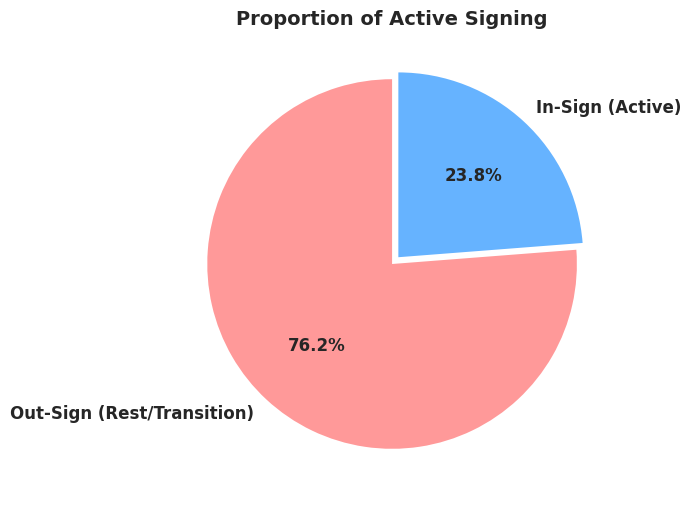

In [ ]:
def format_time(frames, fps):
    seconds = frames / fps
    m, s = divmod(seconds, 60)
    h, m = divmod(m, 60)
    return f"{int(h)}h {int(m)}m {int(s)}s"

out_frames = bio_counts[0]
in_frames = bio_counts[1] + bio_counts[2]

print("="*40)
print("📊 IN-SIGN VS OUT-SIGN ANALYSIS")
print("="*40)
print(f"Total Frames Recorded: {total_frames:,}")
print(f"Total Video Time:      {format_time(total_frames, FPS)}")
print("-" * 40)
print(f"Out-Sign (Resting):    {out_frames:,} frames ({out_frames/total_frames*100:.2f}%) -> {format_time(out_frames, FPS)}")
print(f"In-Sign (Signing):     {in_frames:,} frames ({in_frames/total_frames*100:.2f}%) -> {format_time(in_frames, FPS)}")

# Pie Chart Visualization
plt.figure(figsize=(6, 6))
plt.pie([out_frames, in_frames], labels=['Out-Sign (Rest/Transition)', 'In-Sign (Active)'], 
        autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90, explode=(0, 0.05),
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Proportion of Active Signing', fontsize=14, weight='bold')
plt.show()

🎯 BIO CLASS DISTRIBUTION
0: Outside: 13,243,184 frames (76.2294%)
1: Inside: 3,813,213 frames (21.9493%)
2: Begin: 316,410 frames (1.8213%)


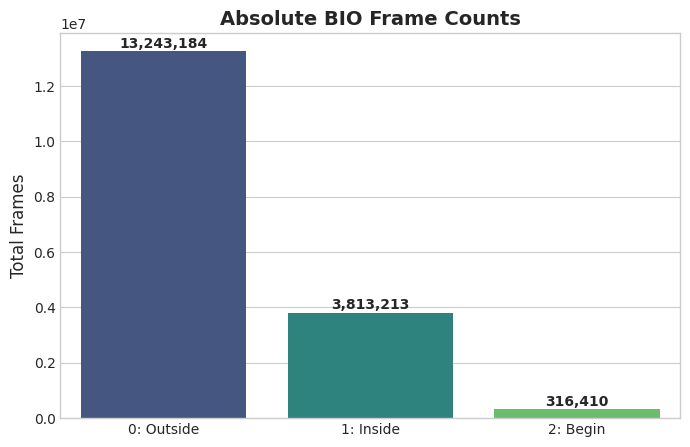

In [ ]:
class_names = ['0: Outside', '1: Inside', '2: Begin']

print("="*40)
print("🎯 BIO CLASS DISTRIBUTION")
print("="*40)
for k, v in bio_counts.items():
    print(f"{class_names[k]}: {v:,} frames ({v/total_frames*100:.4f}%)")

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_names, y=list(bio_counts.values()), hue=class_names, legend=False, palette='viridis')
plt.title('Absolute BIO Frame Counts', fontsize=14, weight='bold')
plt.ylabel('Total Frames', fontsize=12)

# Add comma-separated text labels on top of bars
for i, v in enumerate(bio_counts.values()):
    ax.text(i, v + (max(bio_counts.values())*0.01), f"{v:,}", ha='center', weight='bold')
    
plt.show()

🔍 AVERAGE VERTEX CONFIDENCE BY BIO CLASS
0: Outside: 0.9380 (Max 1.0)
1: Inside: 0.9629 (Max 1.0)
2: Begin: 0.9724 (Max 1.0)


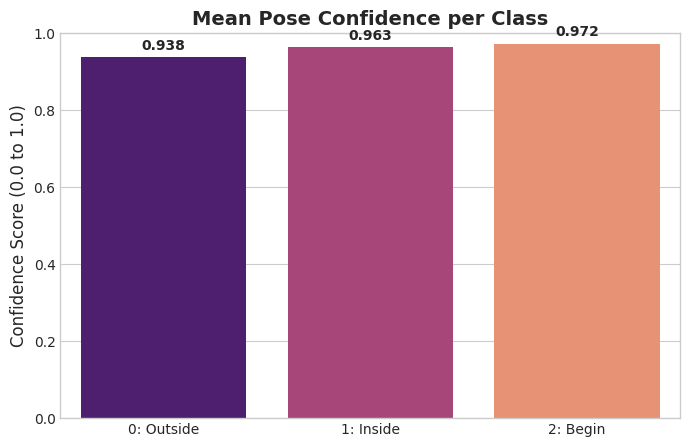

In [ ]:
print("="*40)
print("🔍 AVERAGE VERTEX CONFIDENCE BY BIO CLASS")
print("="*40)
for k, v in bio_avg_conf.items():
    print(f"{class_names[k]}: {v:.4f} (Max 1.0)")

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_names, y=list(bio_avg_conf.values()), hue=class_names, legend=False, palette='magma')
plt.title('Mean Pose Confidence per Class', fontsize=14, weight='bold')
plt.ylabel('Confidence Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.0)

for i, v in enumerate(bio_avg_conf.values()):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', weight='bold')

plt.show()